#normal distribution

#μ  = mean

#σ  = standard deviation

#x  = value of the variable

#f(x) = density at x

PDF does not give the probability of one exact value.
It gives the density.

Probability is found from the area under the curve.

In [3]:
df = pd.read_csv("Galton_Family_Heights.csv")
df.head(10)

,Father_height,Mother_height,Child_height,gender
0,78.5,67.0,73.2,1
1,78.5,67.0,69.2,0
2,78.5,67.0,69.0,0
3,78.5,67.0,69.0,0
4,75.5,66.5,73.5,1
5,75.5,66.5,72.5,1
6,75.5,66.5,65.5,0
7,75.5,66.5,65.5,0
8,75.0,64.0,71.0,1
9,75.0,64.0,68.0,0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load dataset
df = pd.read_csv("Galton_Family_Heights.csv")

# Select child height column
height = df["Child_height"].dropna()

# Calculate mean and standard deviation
mu = height.mean()
sigma = height.std(ddof=1)

print("Mean:", mu)
print("Standard Deviation:", sigma)
print("Median:", height.median())
print("Mode:", height.mode()[0])

Mean: 66.74593147751605
Standard Deviation: 3.5792512015188342
Median: 66.5
Mode: 65.0


In [5]:
height.head(10)

,Child_height
0,73.2
1,69.2
2,69.0
3,69.0
4,73.5
5,72.5
6,65.5
7,65.5
8,71.0
9,68.0


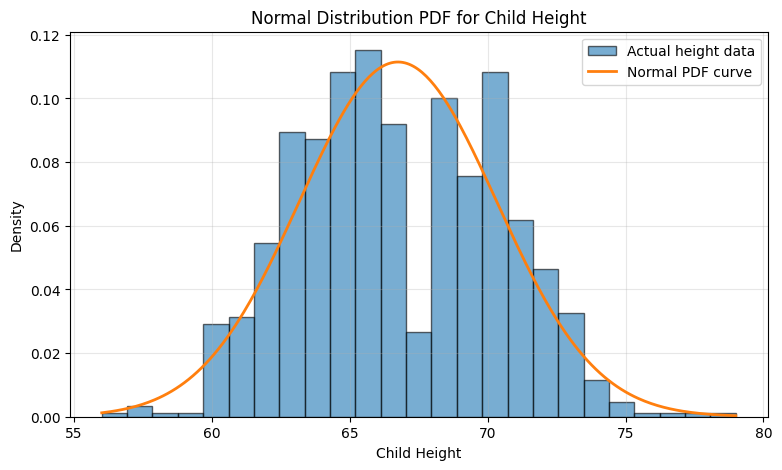

In [6]:
# Create x values for the PDF curve
x = np.linspace(height.min(), height.max(), 300)

# Calculate normal PDF values
pdf_values = norm.pdf(x, mu, sigma)

# Plot histogram and PDF
plt.figure(figsize=(9, 5))

plt.hist(height, bins=25, density=True, edgecolor="black", alpha=0.6, label="Actual height data")
plt.plot(x, pdf_values, linewidth=2, label="Normal PDF curve")

plt.title("Normal Distribution PDF for Child Height")
plt.xlabel("Child Height")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The histogram shows the distribution of child heights in the dataset.
The PDF curve represents the fitted normal distribution using the sample mean and standard deviation.
The graph shows that most child heights are close to the average value, while very short and very tall heights occur less frequently.
This creates the typical bell-shaped pattern of a normal distribution.

# Main Properties of Normal Distribution

1. Bell-shaped curve

The normal distribution has a smooth bell shape.

Most values are near the mean.
Fewer values appear far away from the mean.

2. Symmetry

A perfect normal distribution is symmetric around the mean.

That means the left side and right side of the curve are almost mirror images.


Values below the mean and above the mean are distributed in a balanced way.

3. Mean = Median = Mode

For an ideal normal distribution:

Mean = Median = Mode

4. Controlled by mean and standard deviation

A normal distribution mainly depends on two values:

Mean μ: controls the center of the curve
Standard deviation σ: controls the spread of the curve

5. Total area under the curve is 1

The full area under the PDF curve is always:

1 or 100%

6. Importance of the Central Limit Theorem — CLT

The Central Limit Theorem is one of the most important ideas in statistics.

It says:

If we repeatedly take samples from a population and calculate their means,
the distribution of those sample means will become approximately normal,
especially when the sample size is large.


Raw data may be messy.
But averages of repeated samples become nicely normal.

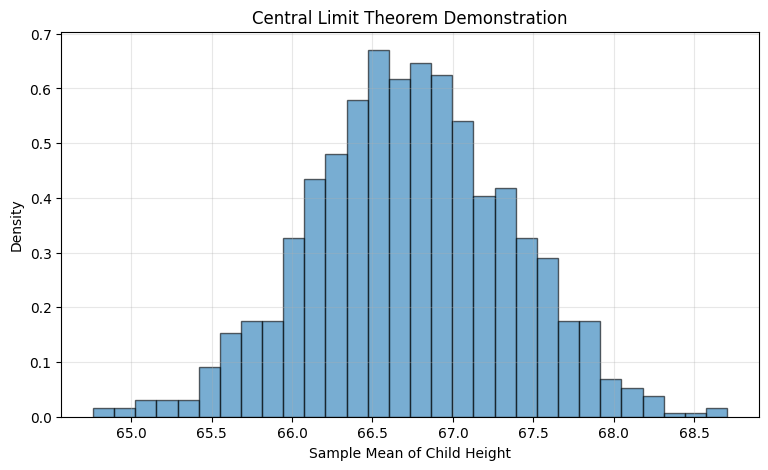

In [7]:
sample_size = 30
number_of_samples = 1000

sample_means = []

for i in range(number_of_samples):
    sample = height.sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

# Plot sampling distribution of the mean
plt.figure(figsize=(9, 5))

plt.hist(sample_means, bins=30, density=True, edgecolor="black", alpha=0.6)

plt.title("Central Limit Theorem Demonstration")
plt.xlabel("Sample Mean of Child Height")
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.show()

This graph shows the distribution of sample means created by repeatedly taking random samples from the child height data.
According to the Central Limit Theorem, the distribution of these sample means becomes approximately normal as the sample size increases.
This demonstrates why the normal distribution is important in statistical inference.

Generate Normal Samples, Plot PDF and CDF
1. Why generate normal samples?

We first estimate the mean and standard deviation from the real height dataset.

Then we generate artificial normal samples using those values.

In simple words:

We use the real dataset to understand the average height and spread.
Then we generate a normal distribution based on those values.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load dataset
df = pd.read_csv("Galton_Family_Heights.csv")

# Select the height column
height = df["Child_height"].dropna()

# Calculate mean and standard deviation from the real data
mu = height.mean()
sigma = height.std(ddof=1)

print("Mean:", mu)
print("Standard Deviation:", sigma)

# Generate normal distribution samples
np.random.seed(42)

normal_samples = np.random.normal(
    loc=mu,        # mean
    scale=sigma,  # standard deviation
    size=1000     # number of generated samples
)

print(normal_samples[:10])

Mean: 66.74593147751605
Standard Deviation: 3.5792512015188342
[68.52379621 66.25104881 69.06417146 72.19723792 65.90783773 65.90789649
 72.39833084 69.49277315 65.06556472 68.68789017]


loc = mean of the distribution

scale = standard deviation of the distribution

size = number of samples to generate


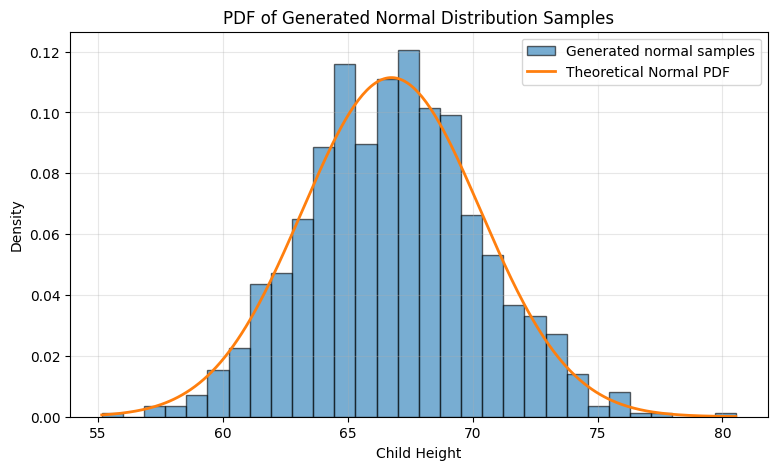

In [9]:
# Create x values
x = np.linspace(normal_samples.min(), normal_samples.max(), 300)

# Calculate PDF values
pdf_values = norm.pdf(x, mu, sigma)

# Plot histogram of generated samples and PDF curve
plt.figure(figsize=(9, 5))

plt.hist(
    normal_samples,
    bins=30,
    density=True,
    edgecolor="black",
    alpha=0.6,
    label="Generated normal samples"
)

plt.plot(
    x,
    pdf_values,
    linewidth=2,
    label="Theoretical Normal PDF"
)

plt.title("PDF of Generated Normal Distribution Samples")
plt.xlabel("Child Height")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The histogram shows the generated normal distribution samples.
The smooth curve represents the theoretical normal PDF based on the calculated mean and standard deviation.
The graph shows that most values are concentrated near the mean, while values far from the mean occur less frequently.
This creates the typical bell-shaped curve of the normal distribution.

#Plot the CDF

It answers questions like:

What is the probability that a child's height is less than or equal to a certain value?

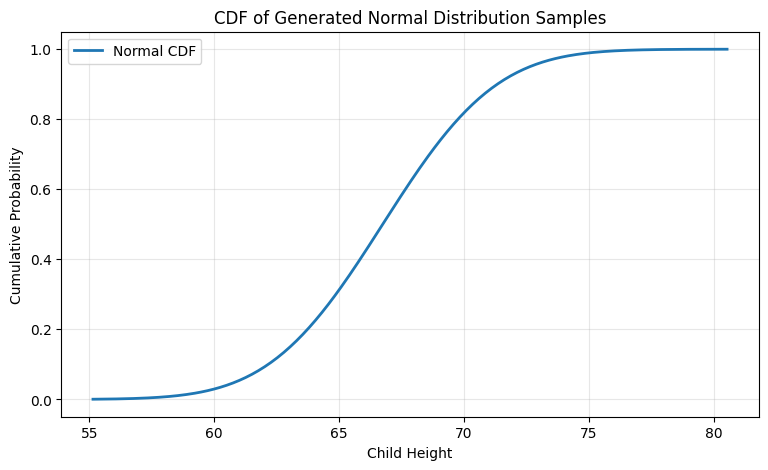

In [10]:
# Calculate CDF values
cdf_values = norm.cdf(x, mu, sigma)

# Plot CDF
plt.figure(figsize=(9, 5))

plt.plot(
    x,
    cdf_values,
    linewidth=2,
    label="Normal CDF"
)

plt.title("CDF of Generated Normal Distribution Samples")
plt.xlabel("Child Height")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The CDF curve shows the cumulative probability of the normal distribution.
As height increases, the cumulative probability also increases.
The curve starts near 0 for very low height values and approaches 1 for very high height values.
This means that the CDF gives the probability of observing a value less than or equal to a given height.

# Explain the 68–95–99.7 Rule

About 68% of values fall within 1 standard deviation from the mean.

About 95% of values fall within 2 standard deviations from the mean.

About 99.7% of values fall within 3 standard deviations from the mean.


In [11]:
print("68% range:", mu - sigma, "to", mu + sigma)
print("95% range:", mu - 2*sigma, "to", mu + 2*sigma)
print("99.7% range:", mu - 3*sigma, "to", mu + 3*sigma)

68% range: 63.166680275997216 to 70.32518267903488
95% range: 59.587429074478386 to 73.90443388055373
99.7% range: 56.00817787295955 to 77.48368508207255


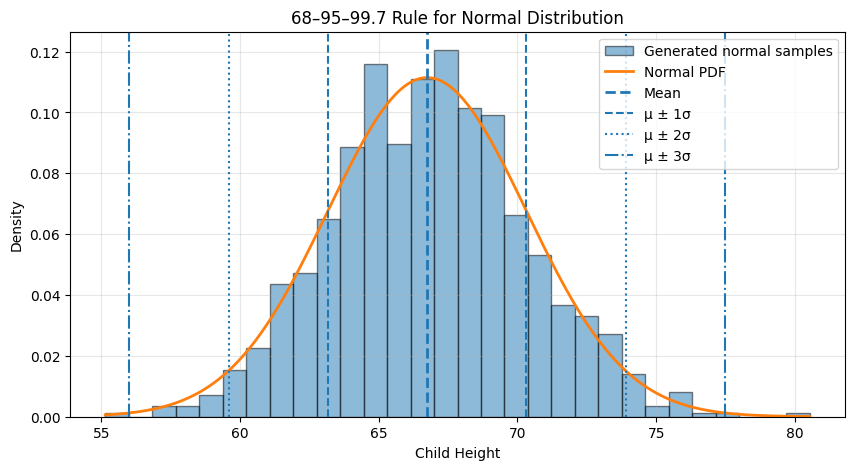

In [12]:
plt.figure(figsize=(10, 5))

# Histogram
plt.hist(
    normal_samples,
    bins=30,
    density=True,
    edgecolor="black",
    alpha=0.5,
    label="Generated normal samples"
)

# PDF curve
plt.plot(
    x,
    pdf_values,
    linewidth=2,
    label="Normal PDF"
)

# Mean line
plt.axvline(mu, linestyle="--", linewidth=2, label="Mean")

# 1 standard deviation
plt.axvline(mu - sigma, linestyle="--", linewidth=1.5, label="μ ± 1σ")
plt.axvline(mu + sigma, linestyle="--", linewidth=1.5)

# 2 standard deviations
plt.axvline(mu - 2*sigma, linestyle=":", linewidth=1.5, label="μ ± 2σ")
plt.axvline(mu + 2*sigma, linestyle=":", linewidth=1.5)

# 3 standard deviations
plt.axvline(mu - 3*sigma, linestyle="-.", linewidth=1.5, label="μ ± 3σ")
plt.axvline(mu + 3*sigma, linestyle="-.", linewidth=1.5)

plt.title("68–95–99.7 Rule for Normal Distribution")
plt.xlabel("Child Height")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()